In [60]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc
from scripts.Hamiltonian import Hamiltonian


In [67]:
widthD = 40

X, Y = widthD, 40
lattice = Lattice(X, Y)

t = 1
T = 0.01

muD = 0.15 * t
mu = np.ones(lattice.X) * muD

U = -6* np.ones(lattice.X)
V_prime = None

V0 = 3 * t
V = V0 * np.ones(lattice.X)

In [68]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.1, 0.1, -0.1, -0.1])

In [73]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=500, temperature=T,verbose=True, mixing=0.6)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.00016614563397819582
Relative error: 0.1987855780739497
Average old: (-0.002918600692412557+0j)
Average: (-0.00292979505993444+0j)
F_xplus:
Absolute error: 0.006966744805879968
Relative error: 0.025062139389778262
Average old: (0.4205938185859089+0j)
Average: (0.4207492808991756+0j)
F_xmin:
Absolute error: 0.006966744805879937
Relative error: 0.025062139389778217
Average old: (0.4205938185859089+0j)
Average: (0.4207492808991755+0j)
F_yplus:
Absolute error: 0.005466491784525146
Relative error: 0.0242926187488546
Average old: (-0.16771933957111324-3.205496783165107e-20j)
Average: (-0.1673748513452672+4.797770346691315e-18j)
F_ymin:
Absolute error: 0.005466491784525146
Relative error: 0.0242926187488546
Average old: (-0.16771933957111324+3.205496783165107e-20j)
Average: (-0.1673748513452672-4.797770346691315e-18j)
Fuu_xplus:
Absolute error: 2.4241489091316437e-16
Relative error: 0.00024240486505523027
Average old: (2.396299104498635e-17+0j)
Average: (9.13350154501527

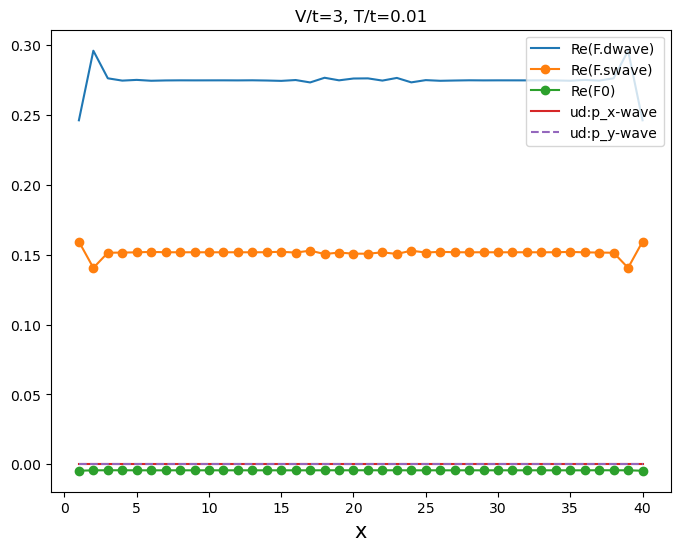

In [75]:
x = np.arange(1, widthD + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.real(F.swave), '-o', label="Re(F.swave)")
axs.plot(x, np.real(H.F0), '-o', label="Re(F0)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [29]:
print(F.dwave[X//2])

(0.35500489166821875+0j)


In [18]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.61 + 1e-12, 0.01)
])  # 109 temps total
print(len(temps))

70


In [ ]:
width = 60
X, Y = width, 60
lattice = Lattice(X, Y)

t = 1
T = 0.01

muP = 1.8 * t
mu = np.ones(lattice.X) * muP

U = None
V_prime = None

V0 = 2 * t
V = V0 * np.ones(lattice.X)
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])


In [ ]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 1.1457058431878386e-15
Relative error: 0.0011457058431878385
Average old: 0j
Average: (-5.0786924491561016e-18+0j)
F_xplus:
Absolute error: 0.3931383509644526
Relative error: 3.931383509605211
Average old: (0.09999999999999999+0j)
Average: (0.1504564722153526+0j)
F_xmin:
Absolute error: 0.39313835096445215
Relative error: 3.931383509683835
Average old: (-0.09999999999999999+0j)
Average: (-0.15045647221535255+0j)
F_yplus:
Absolute error: 0.41324026199859126
Relative error: 4.132402619985913
Average old: 0.10000000000000002j
Average: (3.737534982222945e-17+0.15304152928555753j)
F_ymin:
Absolute error: 0.41324026199859126
Relative error: 4.132402619985913
Average old: -0.10000000000000002j
Average: (3.737534982222945e-17-0.15304152928555753j)
Fuu_xplus:
Absolute error: 2.364887882678576e-16
Relative error: 0.00023648878826785754
Average old: 0j
Average: (-2.5142872724031836e-17+0j)
Fuu_xmin:
Absolute error: 2.9322839094892806e-16
Relative error: 0.00029322839094892805


KeyboardInterrupt: 

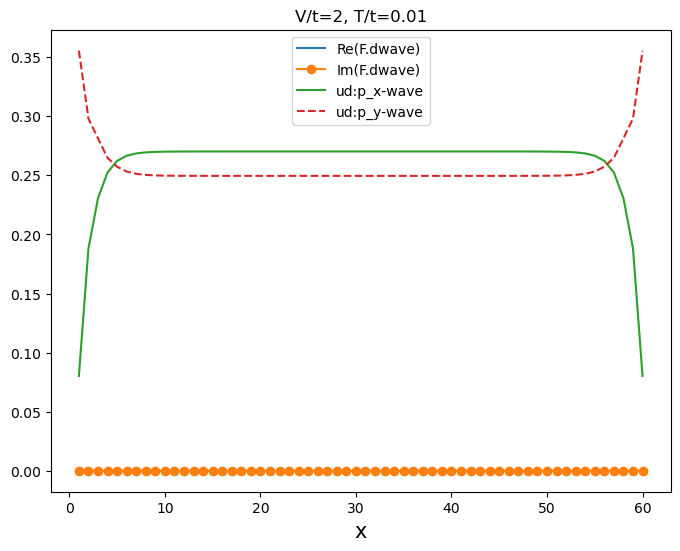

In [ ]:
x = np.arange(1, width + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"V/t={V0}, T/t={T}")
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), '-o', label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.axhline(0.33, linestyle='--', color="red")
axs.legend()
plt.show()

In [ ]:
print(F.py[X//2])
print(F.px[X//2])


0.24956510115604053j
(0.2702341801986249+0j)
